In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open(r'C:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\data\raw\Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv(r'C:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\data\raw\rice.csv', index=False)

print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [2]:
# Read the ARFF file manually
with open(r'C:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\data\raw\Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

In [3]:
print(df)

         Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231.0  525.578979         229.749878          85.093788      0.928882   
1     14656.0  494.311005         206.020065          91.730972      0.895405   
2     14634.0  501.122009         214.106781          87.768288      0.912118   
3     13176.0  458.342987         193.337387          87.448395      0.891861   
4     14688.0  507.166992         211.743378          89.312454      0.906691   
...       ...         ...                ...                ...           ...   
3805  11441.0  415.858002         170.486771          85.756592      0.864280   
3806  11625.0  421.390015         167.714798          89.462570      0.845850   
3807  12437.0  442.498993         183.572922          86.801979      0.881144   
3808   9882.0  392.296997         161.193985          78.210480      0.874406   
3809  11434.0  404.709991         161.079269          90.868195      0.825692   

      Convex_Area    Extent

In [4]:

df.describe().T[['mean','std','min','max']]

,mean,std,min,max
Area,12667.727559,1732.367706,7551.000000,18913.000000
Perimeter,454.239180,35.597081,359.100006,548.445984
Major_Axis_Length,188.776222,17.448679,145.264465,239.010498
Minor_Axis_Length,86.313750,5.729817,59.532406,107.542450
Eccentricity,0.886871,0.020818,0.777233,0.948007
Convex_Area,12952.496850,1776.972042,7723.000000,19099.000000
Extent,0.661934,0.077239,0.497413,0.861050


In [ ]:
#Standardization_(Z-score scaling)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num_cols = df.columns[:-1]
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])

df_std[num_cols].describe().T[['mean','std']]


,mean,std
Area,0.000000e+00,1.000131
Perimeter,-1.193563e-16,1.000131
Major_Axis_Length,0.000000e+00,1.000131
Minor_Axis_Length,-5.371032e-16,1.000131
Eccentricity,5.669422e-16,1.000131
Convex_Area,-4.774250e-16,1.000131
Extent,-4.923446e-16,1.000131


In [6]:
#Min-Max_scaling_(0-1 range)_shown_for_comparison
scaler_mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = scaler_mm.fit_transform(df[num_cols])

df_minmax[num_cols].describe().T[['min','max']]



,min,max
Area,0.0,1.0
Perimeter,0.0,1.0
Major_Axis_Length,0.0,1.0
Minor_Axis_Length,0.0,1.0
Eccentricity,0.0,1.0
Convex_Area,0.0,1.0
Extent,0.0,1.0


FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/member4_scaling_histogram_before.png'

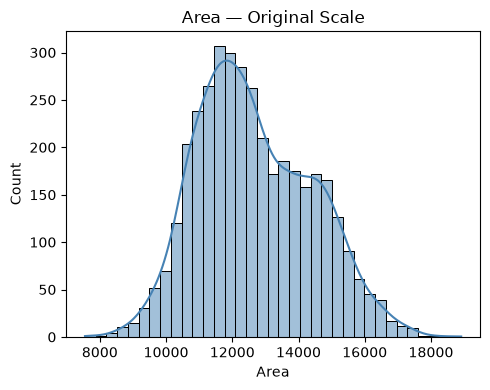

In [7]:
#Before_Scaling_(Original Scale)
plt.figure(figsize=(5, 4))
sns.histplot(df['Area'], kde=True, color='steelblue')
plt.title('Area — Original Scale')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member4_scaling_histogram_before.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/member4_scaling_histogram_after.png'

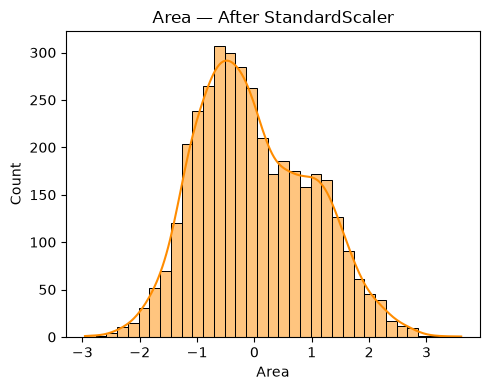

In [8]:
#After_Scaling_(After_StandardScaler)
plt.figure(figsize=(5, 4))
sns.histplot(df_std['Area'], kde=True, color='darkorange')
plt.title('Area — After StandardScaler')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member4_scaling_histogram_after.png', dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/member4_scaling_histogram.png'

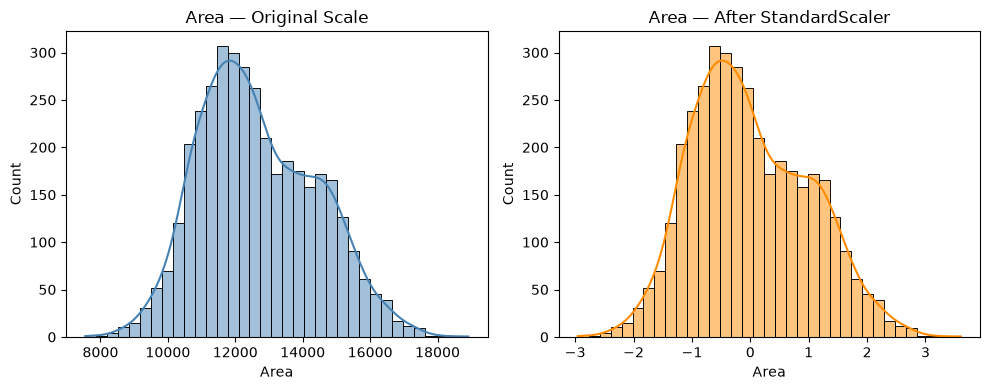

In [9]:
#Before_vs_After
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['Area'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Area — Original Scale')
sns.histplot(df_std['Area'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Area — After StandardScaler')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member4_scaling_histogram.png', dpi=150)
plt.show()
